# Post-processing: ResultLoadsets

## Strut'n'Tie — LUSAS LPI Course Series  
### Video 08

**Author:** Kamil Riedel  
**© Strut'n'Tie**  
**License:** MIT Licence

# Connect to LUSAS

In [1]:
from shared.LPI import *
import shared.Helpers as Helpers

modeller = get_lusas_modeller()
Helpers.initialise(modeller)

if not modeller.existsDatabase():
    raise Exception("A model must be open before running this code")

database = modeller.database()

modeller.getTextWindow().writeLine("Hello World")

# Extract GMNIA increments

In [2]:
# analysis = database.getAnalysis("Analysis 2 - GMNIA")
analyses = database.getAnalyses()
increments = []

for analysis in analyses:
    analysisPrinted = False
    loadcases = analysis.getLoadcases()

    for loadcase in loadcases:
        transientControl = loadcase.getTransientControl()
        if transientControl is not None and transientControl.hasNonlinear():
            if not analysisPrinted:
                print(analysis.getName())
                analysisPrinted = True
            print(f"\n{loadcase.getName()}")
            resultLoadcases = loadcase.getResultsLoadcases()

            for resultLoadcase in resultLoadcases:
                print(resultLoadcase.getName())
                increments.append(resultLoadcase)

Analysis 2 - GMNIA

Vertical
Increment 1

Horizontal
Increment 2 Load Factor = 0.100000
Increment 3 Load Factor = 0.157735
Increment 4 Load Factor = 0.201379
Increment 5 Load Factor = 0.234370
Increment 6 Load Factor = 0.272465
Increment 7 Load Factor = 0.316454
Increment 8 Load Factor = 0.331117
Increment 9 Load Factor = 0.345780
Increment 10 Load Factor = 0.353111
Increment 11 Load Factor = 0.360442
Increment 12 Load Factor = 0.366429
Increment 13 Load Factor = 0.370661
Increment 14 Load Factor = 0.373861
Increment 15 Load Factor = 0.377556
Increment 16 Load Factor = 0.381250
Increment 17 Load Factor = 0.384267
Increment 18 Load Factor = 0.385616
Increment 19 Load Factor = 0.386965
Increment 20 Load Factor = 0.389664
Increment 21 Load Factor = 0.391572
Increment 22 Load Factor = 0.393479
Increment 23 Load Factor = 0.394581
Increment 24 Load Factor = 0.395683
Increment 25 Load Factor = 0.397886
Increment 26 Load Factor = 0.401001
Increment 27 Load Factor = 0.401226
Increment 28 Load F

# Get nodal results

In [3]:
top_node = database.getObject("node", 2)
bottom_node = database.getObject("node", 1)

displacements = []
reactions = []
context = modeller.newResultsContext(None)
context.getShowResultsSet().add("Nodes", "all")

for increment in increments:
    context.setActiveLoadset(increment)
    if top_node.hasResults("Displacement", "Dx", context):
        # dx = top_node.getResults("Displacement", "Dx", context = context)[0] # <== Error
        dx = top_node.getResults("Displacement", "Dx", None, None, context)[0]
        displacements.append(dx)
    if bottom_node.hasResults("Reaction", "FX", context):
        rz = abs(bottom_node.getResults("Reaction", "FX", None, None, context)[0])
        reactions.append(rz)

# Plot the results

08_postprocessing_NL~Analysis 2 - GMNIA.mys


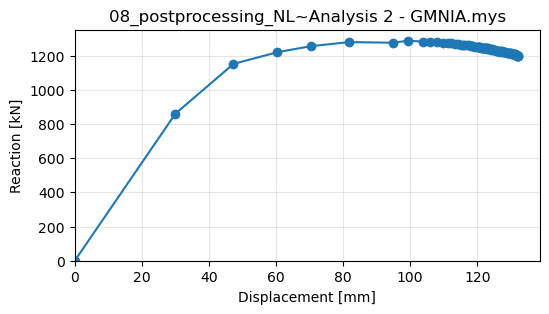

In [4]:
from matplotlib import pyplot as plt

# Get results file name
resultsFile = analysis.getAnalysisResultsFilenames()[0]
resultsFile = resultsFile.split("\\")[-1]
print(resultsFile)

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(displacements, [i/1000 for i in reactions],"-o")
ax.set_ylabel('Reaction [kN]') 
ax.set_xlabel('Displacement [mm]')
ax.set_xlim([0, None])
ax.set_ylim([0, None])
ax.set_title(resultsFile)
ax.grid(True, alpha=0.3)
plt.show()